# Notebook Objectives

This notebook loads the behavior data with the trial by trial neural values (computed by the code ```neural_value_RUN_all_sessions.py```).

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)

---
# Setup


In [1]:
from neural_value_helpers import *
from popy.config import COLORS

plt.rcParams.update({'font.size': 8})


---
# Section 1: Get data (load from file)


In [2]:
behav_new = pd.read_pickle(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', 'behav_neural_value (1)', 'behav.pkl'))
#behav_new = behav_new.loc[behav_new.subregion=='dLPFC']
# remove 5% outliers from dV
#behav_new = behav_new.loc[behav_new['V_t'].abs() < behav_new['V_t'].abs().quantile(0.95)]
behav_new = behav_new.dropna()

In [3]:
#count nans
behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,target_1,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_behav,V_t_p1_behav,dV_behav,V_t_1.5_3.5,V_t_p1_1.5_3.5,dV_1.5_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,False,-0.150551,0.204889,0.355440,0.283056,0.069825,-0.213231,-0.117508,-0.109746,0.007762
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,False,0.204889,-0.059881,-0.264770,0.069825,0.069825,0.000000,-0.109746,-0.055993,0.053753
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,False,-0.059881,-0.200961,-0.141080,0.069825,0.479459,0.409634,-0.055993,0.064920,0.120912
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,False,-0.200961,-0.070287,0.130675,0.479459,0.283056,-0.196402,0.064920,-0.083296,-0.148216
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,False,-0.070287,-0.073770,-0.003484,0.283056,0.167107,-0.115949,-0.083296,0.035119,0.118415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,True,0.796248,0.689507,-0.106742,0.723918,0.503993,-0.219925,0.706391,-0.005228,-0.711619
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,True,0.689507,0.057016,-0.632490,0.503993,0.654679,0.150686,-0.005228,0.390832,0.396059
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,True,0.057016,0.362536,0.305519,0.654679,0.759587,0.104908,0.390832,0.261081,-0.129750
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,True,0.362536,0.786138,0.423602,0.759587,0.832624,0.073037,0.261081,0.440961,0.179879


In [4]:
# normalize dV and V_t per monkey, session, subregion
for time_interval in [(-4, -2), (1.5, 3.5)]:
    behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'dV_{time_interval[0]}_{time_interval[1]}'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] - behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']

behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,target_1,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_behav,V_t_p1_behav,dV_behav,V_t_1.5_3.5,V_t_p1_1.5_3.5,dV_1.5_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,False,-0.769454,0.812984,1.582438,0.283056,0.069825,-0.213231,-0.907589,-0.853688,0.053901
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,False,0.811088,-0.362970,-1.174057,0.069825,0.069825,0.000000,-0.848967,-0.447462,0.401505
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,False,-0.366271,-0.989564,-0.623293,0.069825,0.479459,0.409634,-0.443023,0.466314,0.909337
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,False,-0.993615,-0.409184,0.584431,0.479459,0.283056,-0.196402,0.470115,-0.653801,-1.123917
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,False,-0.412541,-0.424657,-0.012115,0.283056,0.167107,-0.115949,-0.649219,0.241101,0.890320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,True,1.174154,1.031969,-0.142184,0.723918,0.503993,-0.219925,1.895587,-0.036211,-1.931798
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,True,1.031827,0.190688,-0.841139,0.503993,0.654679,0.150686,-0.031474,1.038479,1.069952
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,True,0.188484,0.597062,0.408579,0.654679,0.759587,0.104908,1.041053,0.686407,-0.354646
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,True,0.595854,1.160500,0.564645,0.759587,0.832624,0.073037,0.689690,1.174502,0.484812


---
# Test


SUMMARY COMPARISON ON RECORDED DATA (α = 0.05)
Monkey   Session    Subreg   │ Slope+   Int+     R2+    Reg+?  │ Slope-   Int-     R2-    Reg-?  │ Flat+?   Flat-?   Ident+?    Ident-?    │ Neg vs Pos mean(Vt+1)    │ Hyp
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
ka       010720     MCC      │ 0.382    0.410    0.203  ✔      │ 0.468    -0.435   0.258  ✔      │ ✘        ✘        ✘          ✘          │ Neg < Pos                │ 2  
ka       010720     vLPFC    │ 0.222    0.162    0.050  ✔      │ 0.132    -0.195   0.018  ✘      │ ✘        ✘        ✘          ✘          │ Neg < Pos                │ 4  
ka       010822     MCC      │ 0.126    0.182    0.019  ✘      │ 0.021    -0.267   0.000  ✘      │ ✘        ✔        ✘          ✘          │ Neg < Pos                │ 3  
ka       010822     dLPFC    │ -0.037   0.108    0.001  ✘      │ -0.057   -0.157   0.003  ✘      │

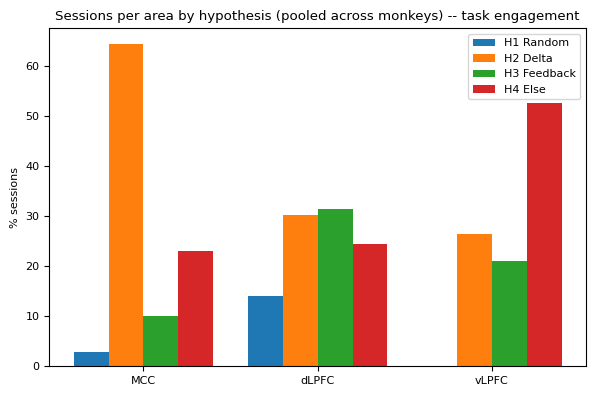

,monkey,session,subregion,mean_vt1_pos,mean_vt1_neg,p_neg_mean_lt_pos,slope_all,intercept_all,r2_all,p_model_all,...,p_model_pos,slope_neg,intercept_neg,r2_neg,p_model_neg,p_pos_gt0,p_pos_lt1,p_neg_gt0,p_neg_lt1,hypothesis
0,ka,010720,MCC,0.462419,-0.506349,4.935083e-26,0.485301,0.000000e+00,0.235517,3.841600e-26,...,2.289881e-12,0.468393,-0.435312,0.258025,1.620756e-14,1.144973e-12,3.039743e-26,8.104628e-15,6.128985e-18,2
1,ka,010720,vLPFC,0.201486,-0.220627,6.228659e-06,0.214696,0.000000e+00,0.046094,9.276389e-06,...,8.927310e-04,0.132338,-0.195063,0.017722,6.021567e-02,4.463655e-04,1.650720e-25,3.010783e-02,8.822357e-27,4
2,ka,010822,MCC,0.181350,-0.266611,4.301236e-05,0.081525,-2.234158e-17,0.006646,1.388554e-01,...,5.459487e-02,0.020985,-0.266862,0.000393,8.200433e-01,2.729743e-02,6.483022e-30,4.100217e-01,9.263368e-20,3
3,ka,010822,dLPFC,0.111729,-0.164258,6.741604e-03,-0.059509,3.112198e-17,0.003541,2.803526e-01,...,6.073198e-01,-0.057459,-0.156559,0.003319,5.084670e-01,6.963401e-01,3.238525e-33,7.457665e-01,1.068984e-23,3
4,ka,010922,MCC,-0.042917,0.062230,7.677539e-01,-0.119316,2.703424e-18,0.014236,9.577310e-02,...,4.446339e-03,0.104301,0.084863,0.012377,3.258796e-01,9.977768e-01,4.428458e-25,1.629398e-01,5.264454e-13,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,po,300322,vLPFC,0.156406,-0.149403,1.103494e-03,0.168418,-1.217993e-17,0.028364,8.020480e-04,...,1.436239e-02,0.176821,-0.137341,0.023100,3.125026e-02,7.181194e-03,4.117547e-34,1.562513e-02,6.346980e-20,2
210,po,300421,MCC,0.375466,-0.409407,2.070675e-15,0.365465,9.601929e-18,0.133565,3.908421e-13,...,3.065797e-06,0.273197,-0.350941,0.092646,3.805969e-05,1.532899e-06,8.750762e-20,1.902984e-05,9.925942e-23,2
211,po,300421,dLPFC,0.122519,-0.133594,7.243668e-03,0.105079,-2.606460e-19,0.011042,4.338461e-02,...,1.154421e-01,0.111325,-0.135177,0.010661,1.714271e-01,5.772105e-02,6.710095e-31,8.571357e-02,6.374250e-22,4
212,po,310822,MCC,0.200089,-0.206310,2.623008e-05,0.670836,7.250436e-17,0.450021,1.398488e-52,...,3.095695e-24,0.688054,-0.071550,0.451375,1.075702e-26,0.000000e+00,4.313201e-12,0.000000e+00,2.437558e-08,2


In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

def summarize_sessions(res_df, alpha=0.05):
    """
    Print per-session table (with an added 'hypothesis' column) and a simple
    count table per monkey × subregion across hypotheses H1–H4.
    Uses Neg vs Pos MEAN(V_{t+1}) comparison (p_neg_mean_lt_pos).
    """
    def lt_alpha(p):  return (pd.notna(p)) and (p < alpha)

    def classify_row(row):
        # regression significance for all trials
        res_all_sig = lt_alpha(row.get('p_model_all'))

        # regression significance for pos/neg
        reg_pos_sig = lt_alpha(row.get('p_model_pos'))
        reg_neg_sig = lt_alpha(row.get('p_model_neg'))

        # Mean comparison (Neg < Pos?)
        neg_mean_lower = lt_alpha(row.get('p_neg_mean_lt_pos'))

        # For significant sides, slopes must be non-zero and non-identity
        pos_ok = True
        if reg_pos_sig:
            pos_ok = lt_alpha(row.get('p_pos_gt0')) and lt_alpha(row.get('p_pos_lt1'))

        neg_ok = True
        if reg_neg_sig:
            neg_ok = lt_alpha(row.get('p_neg_gt0')) and lt_alpha(row.get('p_neg_lt1'))

        # 1) Random : no correlation and no difference in means
        if not res_all_sig and not neg_mean_lower:
            return 1

        # 2) Delta: BOTH regressions significant with valid slopes AND Neg mean < Pos mean
        if (reg_pos_sig and reg_neg_sig) and pos_ok and neg_ok and neg_mean_lower:
            return 2

        # 3) Feedback: both regressions non-significant AND Neg mean < Pos mean
        if not res_all_sig and neg_mean_lower:
            return 3

        # 4) Else
        return 4

    # Compute hypothesis per session and attach to DF (values in {2,3,4}; 1 reserved if you ever re-enable)
    res_df['hypothesis'] = res_df.apply(classify_row, axis=1)

    def mark_nonsig(p):
        if np.isnan(p): return "NaN"
        return "✔" if p >= alpha else "✘"  # ✔ means "nonsignificant" (e.g., flat? / identity?)
    def mark_sig(p):
        if np.isnan(p): return "NaN"
        return "✔" if p < alpha else "✘"

    print("\n" + "="*165)
    print(f"SUMMARY COMPARISON ON RECORDED DATA (α = {alpha:.2f})")
    print("="*165)
    print(f"{'Monkey':<8} {'Session':<10} {'Subreg':<8} │ "
          f"{'Slope+':<8} {'Int+':<8} {'R2+':<6} {'Reg+?':<6} │ "
          f"{'Slope-':<8} {'Int-':<8} {'R2-':<6} {'Reg-?':<6} │ "
          f"{'Flat+?':<8} {'Flat-?':<8} {'Ident+?':<10} {'Ident-?':<10} │ "
          f"{'Neg vs Pos mean(Vt+1)':<24} │ {'Hyp':<3}")
    print("-"*165)

    for _, row in res_df.iterrows():
        # Mean(Vt+1) relation text using p_neg_mean_lt_pos and observed means
        mean_relation = "NaN"
        if not pd.isna(row['p_neg_mean_lt_pos']):
            if row['p_neg_mean_lt_pos'] >= alpha:
                mean_relation = "Neg = Pos"
            else:
                mean_relation = "Neg < Pos" if row['mean_vt1_neg'] < row['mean_vt1_pos'] else "Neg > Pos"

        hyp = int(row['hypothesis']) if pd.notna(row['hypothesis']) else 'NaN'
        print(f"{row['monkey']:<8} {row['session']:<10} {row['subregion']:<8} │ "
              f"{row['slope_pos']:<8.3f} {row['intercept_pos']:<8.3f} {row['r2_pos']:<6.3f} {mark_sig(row['p_model_pos']):<6} │ "
              f"{row['slope_neg']:<8.3f} {row['intercept_neg']:<8.3f} {row['r2_neg']:<6.3f} {mark_sig(row['p_model_neg']):<6} │ "
              f"{mark_nonsig(row['p_pos_gt0']):<8} {mark_nonsig(row['p_neg_gt0']):<8} "
              f"{mark_nonsig(row['p_pos_lt1']):<10} {mark_nonsig(row['p_neg_lt1']):<10} │ "
              f"{mean_relation:<24} │ {hyp:<3}")
    print()

    # Minimal counts per monkey × subregion
    counts = (
        res_df.groupby(['monkey', 'subregion', 'hypothesis'])
              .size()
              .unstack('hypothesis', fill_value=0)
              .reindex(columns=[1, 2, 3, 4], fill_value=0)
              .rename(columns={1: 'H1', 2: 'H2', 3: 'H3', 4: 'H4'})
    )
    if not counts.empty:
        counts['N'] = counts.sum(axis=1)

    print("Counts per Monkey × Subregion (H1–H4):")
    if not counts.empty:
        for (monkey, subregion), row in counts.iterrows():
            print(f"  {monkey} / {subregion}: H1={row['H1']}, H2={row['H2']}, H3={row['H3']}, H4={row['H4']} (N={int(row['N'])})")
    else:
        print("  No sessions to summarize.")
    print()

    # Count sessions per area × hypothesis (pooled across monkeys)
    area_counts = (
        res_df.groupby(['subregion', 'hypothesis'])
              .size()
              .unstack('hypothesis', fill_value=0)
              .reindex(columns=[1, 2, 3, 4], fill_value=0)
    )
    area_counts['N'] = area_counts.sum(axis=1)
    area_counts = area_counts.sort_index()
    area_counts = area_counts.div(area_counts['N'], axis=0) * 100
    area_counts = area_counts.drop(columns=['N'])
    print("Percentage of sessions per area × hypothesis (pooled across monkeys):")

    hyp_labels = ['H1 Random', 'H2 Delta', 'H3 Feedback', 'H4 Else']

    fig, ax = plt.subplots(figsize=(6,4))
    x = range(len(area_counts))
    bar_width = 0.2
    for i, hyp in enumerate([1,2,3,4]):
        ax.bar([pos + i*bar_width for pos in x],
               area_counts[hyp],
               width=bar_width,
               label=hyp_labels[i])
    ax.set_xticks([pos + 1.5*bar_width for pos in x])
    ax.set_xticklabels(area_counts.index)
    ax.set_ylabel("% sessions")
    ax.set_title("Sessions per area by hypothesis (pooled across monkeys) -- task engagement")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return res_df

alpha = 0.05  # significance level

# -----------------------------
# Pick time window & session
# -----------------------------
time_interval = (1.5, 3.5)  # time window for V_t and V_t+1
behav_new['V_t']    = behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']
behav_new['V_t_p1'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}']

res = []  # if not yet defined

for (monkey, session, subregion), behav_new_temp in behav_new.groupby(['monkey', 'session', 'subregion']):

    # Extract datapoints (FILTERED)
    V_t = behav_new_temp['V_t'].values
    V_t1 = behav_new_temp['V_t_p1'].values
    fb_vector = behav_new_temp['feedback'].values

    # shuffle all
    '''np.random.shuffle(fb_vector)
    np.random.shuffle(V_t)
    np.random.shuffle(V_t1)'''

    # Split by feedback
    v_t_neg  = V_t[fb_vector == 0]
    v_t1_neg = V_t1[fb_vector == 0]
    v_t_pos  = V_t[fb_vector == 1]
    v_t1_pos = V_t1[fb_vector == 1]

    # -----------------------------
    # Mean V_t+1 comparison (Neg < Pos?)
    # -----------------------------
    mean_vt1_neg = np.nanmean(v_t1_neg) if len(v_t1_neg) > 0 else np.nan
    mean_vt1_pos = np.nanmean(v_t1_pos) if len(v_t1_pos) > 0 else np.nan

    if len(v_t1_neg) > 1 and len(v_t1_pos) > 1:
        t_mean, p_mean_two = stats.ttest_ind(v_t1_neg, v_t1_pos, equal_var=False, nan_policy='omit')
        # One-tailed p (H1: Neg < Pos)
        p_neg_mean_lt_pos = p_mean_two/2 if t_mean < 0 else 1 - p_mean_two/2
    else:
        p_neg_mean_lt_pos = np.nan

    # -----------------------------
    # Fit separate regressions (guard for n<2)
    # -----------------------------
    def safe_linreg(x, y):
        x = np.asarray(x); y = np.asarray(y)
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]
        if x.size < 2 or y.size < 2:
            return np.nan, np.nan, np.nan, np.nan, np.nan
        return stats.linregress(x, y)

    slope_neg, intercept_neg, r_neg, p_neg, se_slope_neg = safe_linreg(v_t_neg,  v_t1_neg)
    slope_pos, intercept_pos, r_pos, p_pos, se_slope_pos = safe_linreg(v_t_pos,  v_t1_pos)
    slope_all, intercept_all, r_all, p_all, se_slope_all = safe_linreg(V_t,  V_t1)

    # -----------------------------
    # Slope tests (one-tailed) against zero and 1
    # -----------------------------
    df_neg = len(v_t_neg) - 2
    
    t_neg_gt0 = slope_neg / se_slope_neg if se_slope_neg > 0 else np.nan
    p_neg_gt0 = 1 - stats.t.cdf(t_neg_gt0, df_neg) if np.isfinite(t_neg_gt0) else np.nan

    t_neg_lt1 = (slope_neg - 1) / se_slope_neg if se_slope_neg > 0 else np.nan
    p_neg_lt1 = stats.t.cdf(t_neg_lt1, df_neg) if np.isfinite(t_neg_lt1) else np.nan

    df_pos = len(v_t_pos) - 2
    t_pos_gt0 = slope_pos / se_slope_pos if se_slope_pos > 0 else np.nan
    p_pos_gt0 = 1 - stats.t.cdf(t_pos_gt0, df_pos) if np.isfinite(t_pos_gt0) else np.nan

    t_pos_lt1 = (slope_pos - 1) / se_slope_pos if se_slope_pos > 0 else np.nan
    p_pos_lt1 = stats.t.cdf(t_pos_lt1, df_pos) if np.isfinite(t_pos_lt1) else np.nan

    # -----------------------------
    # Package per-session results (trimmed)
    # -----------------------------
    session_result = {
        'monkey': monkey,
        'session': session,
        'subregion': subregion,

        # mean(Vt+1) comparison
        'mean_vt1_pos': mean_vt1_pos,
        'mean_vt1_neg': mean_vt1_neg,
        'p_neg_mean_lt_pos': p_neg_mean_lt_pos,

        # regression summaries
        'slope_all': slope_all,
        'intercept_all': intercept_all,
        'r2_all': np.nan if np.isnan(r_all) else r_all**2,
        'p_model_all': p_all,          # slope 2-sided p in simple LR

        'slope_pos': slope_pos,
        'intercept_pos': intercept_pos,
        'r2_pos': np.nan if np.isnan(r_pos) else r_pos**2,
        'p_model_pos': p_pos,          # slope 2-sided p in simple LR

        'slope_neg': slope_neg,
        'intercept_neg': intercept_neg,
        'r2_neg': np.nan if np.isnan(r_neg) else r_neg**2,
        'p_model_neg': p_neg,          # slope 2-sided p in simple LR

        # one-tailed tests for slope constraints
        'p_pos_gt0': p_pos_gt0,
        'p_pos_lt1': p_pos_lt1,
        'p_neg_gt0': p_neg_gt0,
        'p_neg_lt1': p_neg_lt1,
    }

    res.append(session_result)

res_df = pd.DataFrame(res)

# print summary
summarize_sessions(res_df, alpha=0.05)


Percentage of sessions per area × hypothesis (pooled across monkeys):


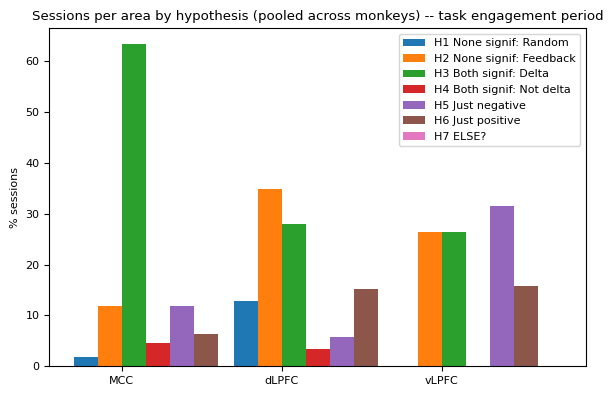

ka / MCC:
  H1: 1 sessions / 58(1.7%)
  H2: 5 sessions / 58(8.6%)
  H3: 41 sessions / 58(70.7%)
  H4: 3 sessions / 58(5.2%)
  H5: 4 sessions / 58(6.9%)
  H6: 4 sessions / 58(6.9%)
  H7: 0 sessions / 58(0.0%)

ka / dLPFC:
  H1: 9 sessions / 46(19.6%)
  H2: 14 sessions / 46(30.4%)
  H3: 10 sessions / 46(21.7%)
  H4: 2 sessions / 46(4.3%)
  H5: 3 sessions / 46(6.5%)
  H6: 8 sessions / 46(17.4%)
  H7: 0 sessions / 46(0.0%)

ka / vLPFC:
  H1: 0 sessions / 12(0.0%)
  H2: 2 sessions / 12(16.7%)
  H3: 2 sessions / 12(16.7%)
  H4: 0 sessions / 12(0.0%)
  H5: 5 sessions / 12(41.7%)
  H6: 3 sessions / 12(25.0%)
  H7: 0 sessions / 12(0.0%)

po / MCC:
  H1: 1 sessions / 51(2.0%)
  H2: 8 sessions / 51(15.7%)
  H3: 28 sessions / 51(54.9%)
  H4: 2 sessions / 51(3.9%)
  H5: 9 sessions / 51(17.6%)
  H6: 3 sessions / 51(5.9%)
  H7: 0 sessions / 51(0.0%)

po / dLPFC:
  H1: 2 sessions / 40(5.0%)
  H2: 16 sessions / 40(40.0%)
  H3: 14 sessions / 40(35.0%)
  H4: 1 sessions / 40(2.5%)
  H5: 2 sessions / 40(5.

,monkey,session,subregion,p_norm_vt,if_norm_vt,p_norm_vt1,if_norm_vt1,p_neg_int_gt_pos,slope_pos,intercept_pos,...,intercept_neg,p_model_neg,p_pos_gt0,p_pos_lt1,p_neg_gt0,p_neg_lt1,lmm_nobs,lmm_aic,lmm_bic,hypothesis
0,ka,010720,MCC,8.025412e-01,False,7.996368e-01,False,0.000000e+00,0.381777,0.409542,...,-0.435312,0.000000,3.169687e-13,1.177164e-31,0.000000,9.064212e-23,419,973.232254,989.383737,3
1,ka,010720,vLPFC,1.793770e-03,True,1.463753e-03,True,9.724128e-05,0.221830,0.162352,...,-0.195063,0.065230,2.880451e-04,7.022532e-34,0.032615,6.119700e-34,419,1161.848371,1177.999855,6
2,ka,010822,MCC,2.210428e-02,True,1.394571e-02,True,1.937964e-05,0.125676,0.182373,...,-0.266862,0.804486,3.495321e-02,9.349054e-37,0.402243,3.744867e-31,331,926.511002,941.719476,2
3,ka,010822,dLPFC,1.469938e-01,False,1.590454e-01,False,9.065690e-03,-0.036710,0.108383,...,-0.156559,0.508444,6.969554e-01,2.429139e-48,0.745778,2.255226e-34,331,939.474931,954.683404,2
4,ka,010922,MCC,2.919456e-03,True,3.044954e-03,True,7.223397e-01,-0.281018,-0.000861,...,0.084863,0.336374,9.984419e-01,1.096983e-41,0.168187,7.546112e-17,196,553.071033,566.183492,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,po,300322,vLPFC,1.011808e-15,True,6.232122e-16,True,2.096166e-03,0.142118,0.146257,...,-0.137341,0.014272,1.861086e-02,1.434949e-36,0.007136,1.919361e-30,393,1102.653761,1118.549000,3
210,po,300421,MCC,5.787709e-01,False,6.092446e-01,False,5.349055e-13,0.322608,0.312150,...,-0.350941,0.000028,6.178624e-07,1.176498e-24,0.000014,3.963805e-29,370,955.737477,971.391489,3
211,po,300421,dLPFC,3.936657e-03,True,2.924590e-03,True,5.970882e-03,0.102604,0.123857,...,-0.135177,0.131985,7.684245e-02,4.942499e-36,0.065993,1.320507e-33,370,1046.564320,1062.218332,2
212,po,310822,MCC,2.825808e-02,True,2.344200e-02,True,2.122468e-02,0.616231,0.083035,...,-0.071550,0.000000,0.000000e+00,8.957638e-12,0.000000,5.687121e-10,392,880.132820,896.017867,3


In [13]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

def summarize_sessions(res_df, alpha=0.05):
    """
    Print per-session table (with an added 'hypothesis' column) and a simple
    count table per monkey × subregion across hypotheses H1–H4.
    Uses Neg vs Pos MEAN(V_{t+1}) comparison (p_neg_mean_lt_pos).
    """
    def lt_alpha(p):  return (pd.notna(p)) and (p < alpha)

    def classify_row(row):
        # regression significance for pos/neg
        reg_pos_sig = lt_alpha(row.get('p_model_pos'))
        reg_neg_sig = lt_alpha(row.get('p_model_neg'))

        # Mean comparison (Neg < Pos?)
        neg_mean_lower = lt_alpha(row.get('p_neg_int_gt_pos'))

        # For significant sides, slopes must be non-zero and non-identity
        pos_ok = True
        if reg_pos_sig:
            pos_ok = lt_alpha(row.get('p_pos_gt0')) and lt_alpha(row.get('p_pos_lt1'))

        neg_ok = True
        if reg_neg_sig:
            neg_ok = lt_alpha(row.get('p_neg_gt0')) and lt_alpha(row.get('p_neg_lt1'))

        # 1) Random : no correlation and no difference in means
        if (not reg_pos_sig and not reg_neg_sig):
            if not neg_mean_lower:
                return 1
            else:
                return 2   # 3) Feedback: both regressions non-significant AND Neg mean < Pos mean
        
        # 2) Delta: BOTH regressions significant with valid slopes AND Neg mean < Pos mean
        elif (reg_pos_sig and reg_neg_sig):
            if pos_ok and neg_ok and neg_mean_lower:
                return 3
            else:
                return 4
        elif (not reg_pos_sig and reg_neg_sig):
            return 5
        elif (reg_pos_sig and not reg_neg_sig):
            return 6
        else:
            return 7

    def plot_hype(res_df, alpha):
        # Count sessions per area × hypothesis (pooled across monkeys)
        area_counts = (
            res_df.groupby(['subregion', 'hypothesis'])
                .size()
                .unstack('hypothesis', fill_value=0)
                .reindex(columns=[1, 2, 3, 4, 5, 6,7], fill_value=0)
        )
        area_counts['N'] = area_counts.sum(axis=1)
        area_counts = area_counts.sort_index()
        area_counts = area_counts.div(area_counts['N'], axis=0) * 100
        area_counts = area_counts.drop(columns=['N'])
        print("Percentage of sessions per area × hypothesis (pooled across monkeys):")

        hyp_labels = ['H1 None signif: Random', 'H2 None signif: Feedback', 'H3 Both signif: Delta', 'H4 Both signif: Not delta', 'H5 Just negative', 'H6 Just positive', 'H7 ELSE?']

        fig, ax = plt.subplots(figsize=(6,4))
        x = range(len(area_counts))
        bar_width = 0.15
        for i, hyp in enumerate([1,2,3,4,5,6,7]):
            ax.bar([pos + i*bar_width for pos in x],
                area_counts[hyp],
                width=bar_width,
                label=hyp_labels[i])
        ax.set_xticks([pos + 1.5*bar_width for pos in x])
        ax.set_xticklabels(area_counts.index)
        ax.set_ylabel("% sessions")
        ax.set_title("Sessions per area by hypothesis (pooled across monkeys) -- task engagement period")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def print_stats(res_df):
        for (monkey, subregion), group in res_df.groupby(['monkey', 'subregion']):
            print(f"{monkey} / {subregion}:")
            counts = group['hypothesis'].value_counts().reindex([1,2,3,4,5,6,7], fill_value=0)
            all = counts.sum()
            total = counts.sum()
            for hyp, count in counts.items():
                percentage = (count / total * 100) if total > 0 else 0
                print(f"  H{hyp}: {count} sessions / {all}({percentage:.1f}%)")
            print()

        # print proportions that are normally distributed
        print("Normality test results (Shapiro-Wilk):")
        print(f"V_t: {res_df['if_norm_vt'].sum()} / {len(res_df)} sessions ({(res_df['if_norm_vt'].sum()/len(res_df))*100:.1f}%) are NOT normally distributed")
        print(f"V_t1: {res_df['if_norm_vt1'].sum()} / {len(res_df)} sessions ({(res_df['if_norm_vt1'].sum()/len(res_df))*100:.1f}%) are NOT normally distributed")

    # Compute hypothesis per session and attach to DF (values in {2,3,4}; 1 reserved if you ever re-enable)
    res_df['hypothesis'] = res_df.apply(classify_row, axis=1)

    plot_hype(res_df, alpha)

    print_stats(res_df)

    return res_df

alpha = 0.05  # significance level

# -----------------------------
# Pick time window & session
# -----------------------------
time_interval = (1.5, 3.5)  # time window for V_t and V_t+1
behav_new['V_t']    = behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']
behav_new['V_t_p1'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}']

res = []  # if not yet defined

for (monkey, session, subregion), behav_new_temp in behav_new.groupby(['monkey', 'session', 'subregion']):

    df = behav_new_temp.copy()

    # Keep rows with finite values and ensure fb is {0,1}
    df = df[np.isfinite(df['V_t']) & np.isfinite(df['V_t_p1']) & np.isfinite(df['feedback'])]
    df['feedback'] = (df['feedback'] > 0).astype(int)

    # shiffle all columns   
    #df = df.apply(lambda x: np.random.permutation(x.values))

    # Alias for clarity with your names
    df = df.rename(columns={'V_t_p1':'V_t1', 'V_t':'Vt', 'feedback':'fb'})

    # normality test for Vt and Vt1
    stat_norm_vt, p_norm_vt = stats.shapiro(df['Vt'])
    stat_norm_vt1, p_norm_vt1 = stats.shapiro(df['V_t1'])

    # --- Fit mixed model: random intercept & Vt slope by session
    # If you have a 'session' column already, great. Otherwise set session as provided arg.
    #if 'session' not in df.columns:
    #    df['session'] = session
    #md = smf.mixedlm("V_t1 ~ Vt * fb", data=df, groups="session", re_formula="~Vt")
    m = smf.ols("V_t1 ~ Vt*fb", data=df).fit()

    # Fixed effects
    # Param names: Intercept, Vt, fb, Vt:fb
    b = m.params
    se = m.bse

    # Group-specific intercepts and slopes:
    intercept_neg = b['Intercept']                         # fb=0
    slope_neg     = b['Vt']
    intercept_pos = b['Intercept'] + b['fb']               # fb=1
    slope_pos     = b['Vt'] + b['Vt:fb']

    # One-sided Wald test: H1 fb < 0  (i.e., intercept_neg > intercept_pos)
    z = b['fb'] / se['fb']
    p_neg_int_gt_pos = 1 - stats.norm.cdf(z)   # but since diff = -fb, this equals stats.norm.cdf(z_fb)

    # One-tailed slope tests using normal approx (statsmodels MixedLM uses large-sample z)
    def one_tailed_greater(est, se_):
        z = est / se_
        return 1 - stats.norm.cdf(z)

    def one_tailed_less_than(est, se_, c):
        # H1: est < c
        z = (est - c) / se_
        return stats.norm.cdf(z)

    # Get SEs for linear combos:
    # slope_neg = Vt
    se_slope_neg = se['Vt']
    # slope_pos = Vt + Vt:fb -> need combo SE from cov matrix
    cov = m.cov_params()
    se_slope_pos = np.sqrt(cov.loc['Vt','Vt'] + cov.loc['Vt:fb','Vt:fb'] + 2*cov.loc['Vt','Vt:fb'])

    # Tests vs 0 and 1
    p_neg_gt0 = one_tailed_greater(slope_neg, se_slope_neg)
    p_neg_lt1 = one_tailed_less_than(slope_neg, se_slope_neg, 1.0)
    p_pos_gt0 = one_tailed_greater(slope_pos, se_slope_pos)
    p_pos_lt1 = one_tailed_less_than(slope_pos, se_slope_pos, 1.0)

    # Package results to mirror your schema, sourcing from the mixed model where appropriate
    session_result = {
        'monkey': monkey,
        'session': session,
        'subregion': subregion,

        # normality tests
        'p_norm_vt': p_norm_vt,
        'if_norm_vt': p_norm_vt < 0.05,
        'p_norm_vt1': p_norm_vt1,
        'if_norm_vt1': p_norm_vt1 < 0.05,

        # mean(Vt+1) comparison via intercept difference
        #'mean_vt1_pos': mean_vt1_pos,
        #'mean_vt1_neg': mean_vt1_neg,
        'p_neg_int_gt_pos': p_neg_int_gt_pos,  # from LMM (fb effect > 0)

        # group-specific slopes/intercepts from the MIXED MODEL (not from LR)
        'slope_pos': slope_pos,
        'intercept_pos': intercept_pos,
        'p_model_pos': 2*(1 - stats.norm.cdf(abs(slope_pos/se_slope_pos))),  # two-sided Wald

        'slope_neg': slope_neg,
        'intercept_neg': intercept_neg,
        'p_model_neg': 2*(1 - stats.norm.cdf(abs(slope_neg/se_slope_neg))),  # two-sided Wald

        # one-tailed slope constraints from the MIXED MODEL
        'p_pos_gt0': p_pos_gt0,
        'p_pos_lt1': p_pos_lt1,
        'p_neg_gt0': p_neg_gt0,
        'p_neg_lt1': p_neg_lt1,

        # model diagnostics
        #'lmm_converged': m.converged,
        'lmm_nobs': int(m.nobs),
        'lmm_aic': float(m.aic),
        'lmm_bic': float(m.bic),
    }

    res.append(session_result)

res_df = pd.DataFrame(res)

# print summary
res_df = summarize_sessions(res_df, alpha=0.05)
res_df

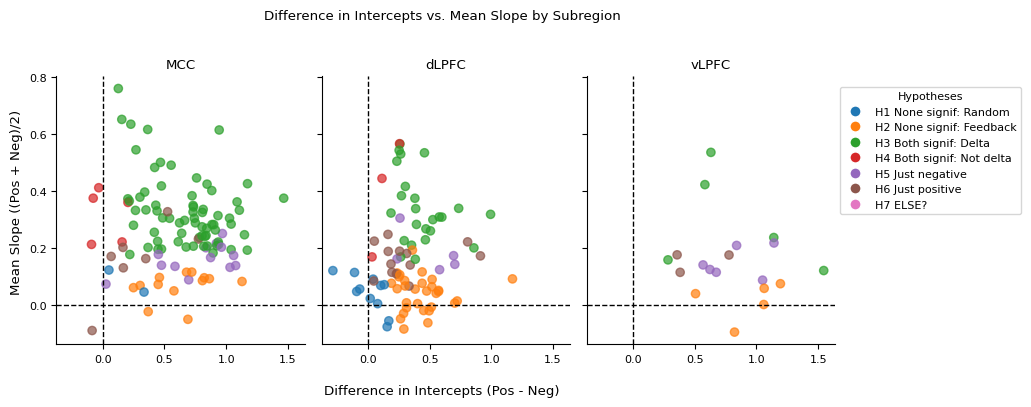

In [26]:
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns  # uncomment if you want sns.despine()

# --- prepare a color map once ---
color_map = {
    1: 'tab:blue', 2: 'tab:orange', 3: 'tab:green', 4: 'tab:red',
    5: 'tab:purple', 6: 'tab:brown', 7: 'tab:pink'
}
hyp_labels = [
    'H1 None signif: Random', 'H2 None signif: Feedback', 'H3 Both signif: Delta',
    'H4 Both signif: Not delta', 'H5 Just negative', 'H6 Just positive', 'H7 ELSE?'
]

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=hyp_labels[i-1],
           markerfacecolor=color_map[i], markersize=8)
    for i in range(1, 8)
]

# --- choose/ensure exactly three subregions in a stable order ---
subregions = list(res_df['subregion'].dropna().unique())
subregions = sorted(subregions)[:3]  # adjust if you want a specific order

# --- helper to compute arrays for a given subregion ---
def compute_points_for_subregion(df_sub):
    d_interceptions = []
    mean_slopes = []
    hypotheses = []
    # group within subregion by (monkey, session)
    for (monkey, session), behav_new_temp in df_sub.groupby(['monkey', 'session']):
        d_interceptions.append(
            behav_new_temp['intercept_pos'].values - behav_new_temp['intercept_neg'].values
        )
        mean_slope = (behav_new_temp['slope_neg'].values + behav_new_temp['slope_pos'].values) / 2
        hypotheses.append(behav_new_temp['hypothesis'].values)
        mean_slopes.append(mean_slope)

    if len(d_interceptions) == 0:
        return np.array([]), np.array([]), np.array([])

    d_interceptions = np.concatenate(d_interceptions)
    mean_slopes = np.concatenate(mean_slopes)
    hypotheses = np.concatenate(hypotheses)
    return d_interceptions, mean_slopes, hypotheses

# --- collect data and global limits first (so shared axes are meaningful) ---
per_sub = {}
all_x, all_y = [], []
for sub in subregions:
    df_sub = res_df[res_df['subregion'] == sub]
    x, y, h = compute_points_for_subregion(df_sub)
    per_sub[sub] = (x, y, h)
    if x.size:
        all_x.append(x)
        all_y.append(y)

# fall back to (0,1) if empty
if all_x:
    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    xpad = 0.05 * (all_x.max() - all_x.min() if all_x.size else 1.0)
    ypad = 0.05 * (all_y.max() - all_y.min() if all_y.size else 1.0)
    xlim = (all_x.min() - xpad, all_x.max() + xpad)
    ylim = (all_y.min() - ypad, all_y.max() + ypad)
else:
    xlim = (-1, 1)
    ylim = (-1, 1)

# --- make subplots ---
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharex=True, sharey=True)

for ax, sub in zip(axes, subregions):
    x, y, h = per_sub[sub]
    if x.size:
        colors = [color_map[int(hh)] for hh in h]
        ax.scatter(x, y, c=colors, alpha=0.7)
    # reference lines
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(1, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{sub}')
    # sns.despine(ax=ax)  # uncomment if using seaborn

# shared labels & limits
for ax in axes:
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    sns.despine(ax=ax)  # uncomment if using seaborn

fig.suptitle('Difference in Intercepts vs. Mean Slope by Subregion', y=0.98)
fig.supxlabel('Difference in Intercepts (Pos - Neg)')
fig.supylabel('Mean Slope ((Pos + Neg)/2)')

# single legend for the whole figure
fig.legend(handles=legend_elements, title='Hypotheses', loc='upper right', bbox_to_anchor=(1.15, .8))

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()


print an example session

(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='$V_t$', ylabel='$V_{t+1}$'>)

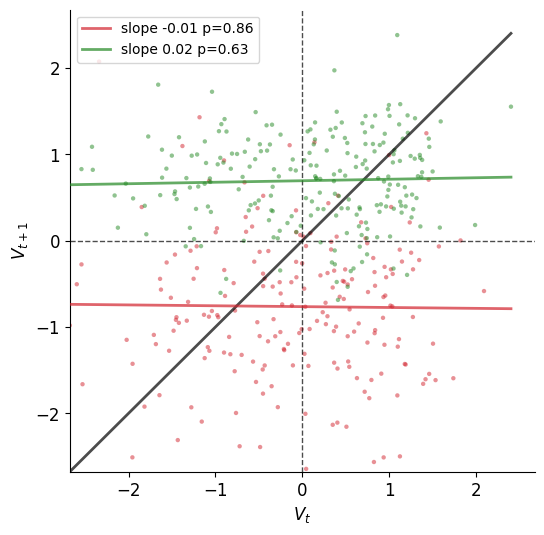

In [ ]:
monkey, session, subregion = 'ka', '010720', 'vLPFC'
behav_new_temp = behav_new[(behav_new.monkey==monkey) & (behav_new.session==session) & (behav_new.subregion==subregion)]
'''
monkeys = ['ka', 'po']
area = 'MCC'
sessions = res_df.loc[(res_df.monkey.isin(monkeys)) & (res_df.subregion==area) & (res_df.hypothesis==4), 'session'].unique()
    
behav_new_temp = behav_new[(behav_new.monkey.isin(monkeys)) & (behav_new.subregion==area) & (behav_new.session.isin(sessions))]
print(f"Plotting {len(behav_new_temp)} trials from {len(sessions)} sessions in {area} for monkeys {monkeys} (H2 Delta rule)")

# Example usage:
V_t = behav_new_temp['V_t'].values
V_t1 = behav_new_temp['V_t_p1'].values
fb_vector = behav_new_temp['feedback'].values
'''
# random shuffling all

green_red_plot(behav_new_temp, paper_format=False)

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# === Extra helpers ===
def two_tailed_from_t(t, df):
    if not np.isfinite(t) or df is None or df <= 0:
        return np.nan
    return 2 * (1 - stats.t.cdf(abs(t), df))

def p_eq1_two(slope, se, df):
    if not (np.isfinite(slope) and np.isfinite(se) and se > 0 and df > 0):
        return np.nan
    t = (slope - 1.0) / se
    return two_tailed_from_t(t, df)

def p_eq0_two(slope, se, df):
    if not (np.isfinite(slope) and np.isfinite(se) and se > 0 and df > 0):
        return np.nan
    t = slope / se
    return two_tailed_from_t(t, df)

def compare_slopes_two_tailed(slope_pos, se_pos, n_pos, slope_neg, se_neg, n_neg):
    """Welch test on slope difference (independent fits)."""
    if any([se_pos is None, se_neg is None]):
        return np.nan
    if not all(np.isfinite([slope_pos, se_pos, slope_neg, se_neg])) or se_pos<=0 or se_neg<=0:
        return np.nan
    diff = slope_pos - slope_neg
    se_diff2 = se_pos**2 + se_neg**2
    t = diff / np.sqrt(se_diff2)
    # Welch-Satterthwaite df using SE^2 as variance proxies
    v1, v2 = se_pos**2, se_neg**2
    df1 = (n_pos - 2) if n_pos is not None else None
    df2 = (n_neg - 2) if n_neg is not None else None
    if df1 is None or df2 is None or df1<=0 or df2<=0: 
        return np.nan
    df_w = (se_diff2**2) / ((v1**2)/df1 + (v2**2)/df2)
    return two_tailed_from_t(t, df_w)

def intercept_tests(vx, vy, slope, intercept):
    """Return se_b0 and df for intercept using standard OLS formula."""
    n = len(vx)
    if n <= 2 or not np.isfinite(slope) or not np.isfinite(intercept):
        return np.nan, np.nan
    y_hat = slope * vx + intercept
    resid = vy - y_hat
    df = n - 2
    if df <= 0:
        return np.nan, np.nan
    s2 = np.sum(resid**2) / df
    x_bar = np.mean(vx)
    Sxx = np.sum((vx - x_bar)**2)
    if Sxx <= 0:
        return np.nan, df
    se_b0 = np.sqrt(s2 * (1/n + (x_bar**2)/Sxx))
    return se_b0, df

# === Build everything needed for hypothesis decisions ===
alpha = 0.05
# We’ll need SEs and dfs again (store n’s for Welch tests)
res_df['n_pos'] = np.nan
res_df['n_neg'] = np.nan
res_df['se_slope_pos'] = np.nan
res_df['se_slope_neg'] = np.nan
res_df['df_pos'] = np.nan
res_df['df_neg'] = np.nan
res_df['se_intercept_pos'] = np.nan
res_df['se_intercept_neg'] = np.nan
res_df['df_b0_pos'] = np.nan
res_df['df_b0_neg'] = np.nan

# If you still have the trial-wise data handy, fill these; otherwise, we can backfill
# se_slope_* and df_* from your earlier variables. If not available, the equality
# tests that need SEs will become NaN and won’t trigger "Random update".
# Here we try to recover from columns present in your earlier loop if they exist:
for idx, row in res_df.iterrows():
    # Attempt to pull stored SEs from your pipeline if present
    for col in ['se_slope_pos','se_slope_neg','df_pos','df_neg','se_intercept_pos','se_intercept_neg','df_b0_pos','df_b0_neg','n_pos','n_neg']:
        if col in res_df.columns and pd.notna(row.get(col, np.nan)):
            continue  # already filled
    # We can’t reconstruct from aggregate table alone; leave NaNs.
    pass

# Compute p-values for equality to 1 and 0 where possible
res_df['p_pos_eq1_two'] = p_eq1_two(res_df['slope_pos'], res_df['se_slope_pos'], res_df['df_pos'])
res_df['p_neg_eq1_two'] = p_eq1_two(res_df['slope_neg'], res_df['se_slope_neg'], res_df['df_neg'])
res_df['p_pos_eq0_two'] = p_eq0_two(res_df['slope_pos'], res_df['se_slope_pos'], res_df['df_pos'])
res_df['p_neg_eq0_two'] = p_eq0_two(res_df['slope_neg'], res_df['se_slope_neg'], res_df['df_neg'])

# Two-tailed slope difference (pos vs neg)
res_df['p_diff_slopes_two'] = compare_slopes_two_tailed(
    res_df['slope_pos'], res_df['se_slope_pos'], res_df['n_pos'],
    res_df['slope_neg'], res_df['se_slope_neg'], res_df['n_neg']
)

# Two-tailed intercept equality (pos vs neg)
# We already have one-tailed p for Neg<Pos in 'p_neg_intercept_lt_pos'
# Add a two-tailed version for "no difference" checks:
def intercept_two_tailed(row):
    se_pos = row['se_intercept_pos']
    se_neg = row['se_intercept_neg']
    df_pos = row['df_b0_pos']
    df_neg = row['df_b0_neg']
    b0_pos = row['intercept_pos']
    b0_neg = row['intercept_neg']
    if not all(np.isfinite([se_pos, se_neg, df_pos, df_neg, b0_pos, b0_neg])) or se_pos<=0 or se_neg<=0 or df_pos<=0 or df_neg<=0:
        return np.nan
    diff = b0_neg - b0_pos
    se_diff = np.sqrt(se_pos**2 + se_neg**2)
    t = diff / se_diff
    v1, v2 = se_pos**2, se_neg**2
    df_w = ((v1 + v2)**2) / ((v1**2)/df_pos + (v2**2)/df_neg)
    return two_tailed_from_t(t, df_w)

if 'se_intercept_pos' in res_df and 'se_intercept_neg' in res_df:
    res_df['p_intercepts_equal_two'] = res_df.apply(intercept_two_tailed, axis=1)
else:
    res_df['p_intercepts_equal_two'] = np.nan

# One-tailed test: positive intercept > 0
def p_pos_intercept_gt0(row):
    b0 = row['intercept_pos']
    se = row['se_intercept_pos']
    df = row['df_b0_pos']
    if not all(np.isfinite([b0, se, df])) or se<=0 or df<=0:
        return np.nan
    t = b0 / se
    return 1 - stats.t.cdf(t, df)

res_df['p_pos_intercept_gt0'] = res_df.apply(p_pos_intercept_gt0, axis=1)

# === Hypothesis decision rules (exactly as you specified) ===
def assign_hypothesis(row, alpha=alpha, eps=1e-6):
    # Convenience accessors
    pos_gt0 = row['p_pos_gt0']; neg_gt0 = row['p_neg_gt0']
    pos_lt1 = row['p_pos_lt1']; neg_lt1 = row['p_neg_lt1']
    pos_eq1 = row['p_pos_eq1_two']; neg_eq1 = row['p_neg_eq1_two']
    pos_eq0 = row['p_pos_eq0_two']; neg_eq0 = row['p_neg_eq0_two']
    p_diff_slopes = row['p_diff_slopes_two']
    p_intercepts_equal = row['p_intercepts_equal_two']
    p_neg_lt_pos = row['p_neg_intercept_lt_pos']
    p_pos_b0_gt0 = row['p_pos_intercept_gt0']

    # 1) Random update:
    #    slope == identity (both ≈1) AND no difference between pos/neg slopes AND no difference between pos/neg intercepts
    cond_random = (
        (pd.notna(pos_eq1) and pos_eq1 >= alpha) and
        (pd.notna(neg_eq1) and neg_eq1 >= alpha) and
        (pd.notna(p_diff_slopes) and p_diff_slopes >= alpha) and
        (pd.notna(p_intercepts_equal) and p_intercepts_equal >= alpha)
    )

    # 2) Delta rule:
    #    both slopes strictly between 0 and 1 (i.e., slope>0 and slope<1 are significant)
    #    AND positive intercept higher than negative (Neg < Pos) significantly
    cond_delta = (
        (pd.notna(pos_gt0) and pos_gt0 < alpha) and
        (pd.notna(neg_gt0) and neg_gt0 < alpha) and
        (pd.notna(pos_lt1) and pos_lt1 < alpha) and
        (pd.notna(neg_lt1) and neg_lt1 < alpha) and
        (pd.notna(p_neg_lt_pos) and p_neg_lt_pos < alpha)
    )

    # 3) Feedback representation:
    #    slopes are flat (≈0) for both (i.e., not significantly different from 0, two-tailed)
    #    AND positive intercept > 0 (one-tailed)
    cond_feedback = (
        (pd.notna(pos_eq0) and pos_eq0 >= alpha) and
        (pd.notna(neg_eq0) and neg_eq0 >= alpha) and
        (pd.notna(p_pos_b0_gt0) and p_pos_b0_gt0 < alpha)
    )

    if cond_random:
        return "random update"
    elif cond_delta:
        return "delta rule"
    elif cond_feedback:
        return "feedback representation"
    else:
        return "none"

res_df['hypothesis'] = res_df.apply(assign_hypothesis, axis=1)

# === Per-monkey × subregion counts ===
counts = (
    res_df
    .groupby(['monkey','subregion','hypothesis'], dropna=False)
    .size()
    .reset_index(name='n_sessions')
    .sort_values(['monkey','subregion','hypothesis'])
    .reset_index(drop=True)
)

# === Sorted session table (as requested) ===
res_df_sorted = (
    res_df
    .sort_values(['monkey','subregion','hypothesis','session'])
    .reset_index(drop=True)
)

# Show results
print("\nPer-monkey × subregion hypothesis counts:")
print(counts)

print("\nSession table (sorted by monkey, subregion, hypothesis, session):")
print(res_df_sorted[['monkey','session','subregion','hypothesis',
                     'slope_pos','slope_neg','intercept_pos','intercept_neg',
                     'p_pos_gt0','p_pos_lt1','p_neg_gt0','p_neg_lt1',
                     'p_pos_eq0_two','p_neg_eq0_two','p_pos_eq1_two','p_neg_eq1_two',
                     'p_intercepts_equal_two','p_neg_intercept_lt_pos','p_pos_intercept_gt0']])


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

---
# Section 2: Analysis of the neural value representation

## History in the subspace

### Short history

In [ ]:
monkeys = 'both' # 'both', 'two'

n_perms = 1000  # number of permutations for CPD analysis

for time_interval in [(-4, -2), (1.5, 3.5)]:  
    # rename columns for plotting: V_T_... to V_t, dV_... to dV
    behav_new['V_t'] = behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']
    behav_new['V_t_p1'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}']
    behav_new['dV'] = behav_new[f'dV_{time_interval[0]}_{time_interval[1]}']

    # for each monkey, session, subregion, fb_sequence, take a mean of these columns
    behav_new_sess_avg_sequence = behav_new.copy().groupby(['monkey', 'session', 'subregion', 'fb_sequence'])['V_t'].mean().reset_index()

    behav_new_sess_avg_fb = []
    for (monkey, session, subregion), group in behav_new.groupby(['monkey', 'session', 'subregion']):
        U, pval = stats.mannwhitneyu(group.loc[group['feedback'] == 0, 'dV'], group.loc[group['feedback'] == 1, 'dV'], alternative='two-sided')
        for fb in group['feedback'].unique():
            behav_new_sess_avg_fb.append({
                'monkey': monkey,
                'session': session,
                'subregion': subregion,
                'feedback': fb,
                'V_t': group.loc[group['feedback'] == fb, 'V_t'].mean(),
                'V_t_p1': group.loc[group['feedback'] == fb, 'V_t_p1'].mean(),
                'dV': group.loc[group['feedback'] == fb, 'dV'].mean(),
                'U': U,
                'signif': pval < 0.05
            })
    behav_new_sess_avg_fb = pd.DataFrame(behav_new_sess_avg_fb)
        

    # calculate simple GLM weights for each session, subregion, monkey
    weights_all = simple_glm_weights(behav_new)

    # Main analysis with joblib parallelization
    cpd_all = get_cpd_all(behav_new, n_perms)

    # Plotting
    if monkeys == 'two':
        # font = 8
        plt.rcParams.update({'font.size': 8})
        fig1, axs1 = plt.subplots(2, 3, figsize=(8, 5), sharex=True, sharey=True)
        fig2, axs2 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig3, axs3 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig4, axs4 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig5, axs5 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)

        for m, monkey in enumerate(behav_new['monkey'].unique()):
            for s, subregion in enumerate(behav_new['subregion'].unique()):
                # filter data for the current monkey and subregion
                behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[(behav_new_sess_avg_sequence['monkey'] == monkey) & (behav_new_sess_avg_sequence['subregion'] == subregion)]
                behav_new_sess_avg_fb_temp = behav_new_sess_avg_fb.loc[(behav_new_sess_avg_fb['monkey'] == monkey) & (behav_new_sess_avg_fb['subregion'] == subregion)]

                weights_all_temp = weights_all.loc[(weights_all['monkey'] == monkey) & (weights_all['subregion'] == subregion)]
                cpd_all_temp = cpd_all.loc[(cpd_all['monkey'] == monkey) & (cpd_all['subregion'] == subregion)]
                null_temp = create_permutation_null(behav_new.loc[(behav_new['monkey'] == monkey) & (behav_new['subregion'] == subregion)], n_perms=n_perms)

                ax = axs1[m, s]
                plot_Vt_per_sequence(behav_new_sess_avg_sequence_temp, paper_format=False, ylim=None, show_datapoints=True, showfliers=False, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs2[m, s]
                plot_dV_per_fb(behav_new_sess_avg_fb_temp, paper_format=False, ylim=None, show_datapoints=False, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs3[m, s]
                green_red_plot(behav_new_sess_avg_fb_temp, paper_format=False, ylim=None, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs4[m, s]
                plot_simple_glm_weights(weights_all_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

                ax = axs5[m, s]
                plot_prop_signif_sessions(cpd_all_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

                ax = axs6[m, s]
                plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)


        # save figure
        #fig.savefig(f'figs/all_sess_neural_value_projection.svg', bbox_inches='tight', transparent=True)

    else:
        # font = 8
        plt.rcParams.update({'font.size': 8})
        fig1, axs1 = plt.subplots(1, 3, figsize=(7.5, 1.5), sharex=True, sharey=True)
        fig2, axs2 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig3, axs3 = plt.subplots(1, 3, figsize=(5, 1.5)) 
        fig4, axs4 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig5, axs5 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig6, axs6 = plt.subplots(1, 3, figsize=(7.5, 1.5), sharex=True, sharey=True)

        monkey = 'both monkeys'

        for s, subregion in enumerate(behav_new['subregion'].unique()):
            behav_new_temp = behav_new.loc[behav_new['subregion'] == subregion]
            behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[behav_new_sess_avg_sequence['subregion'] == subregion]
            behav_new_sess_avg_feed_temp = behav_new_sess_avg_fb.loc[behav_new_sess_avg_fb['subregion'] == subregion]

            weights_all_temp = weights_all.loc[weights_all['subregion'] == subregion]
            cpd_all_temp = cpd_all.loc[cpd_all['subregion'] == subregion]
            null_temp = create_permutation_null(behav_new.loc[behav_new['subregion'] == subregion], n_perms=n_perms)

            ax = axs1[s]
            plot_Vt_per_sequence(behav_new_sess_avg_sequence_temp, paper_format=True, ylim=[-1.5, 1.5], show_datapoints=True, showfliers=False, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_sequence_temp["session"].unique())} sess.', fontsize=8)

            ax = axs2[s]
            create_r_style_plot(ax, behav_new_sess_avg_feed_temp, 'feedback', 'dV')
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_feed_temp["session"].unique())} sess.', fontsize=8)

            ax = axs3[s]
            green_red_plot(behav_new_temp.dropna(), paper_format=True, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_temp["session"].unique())} sess.', fontsize=8)

            ax = axs4[s]
            plot_simple_glm_weights(weights_all_temp, ax=ax, show_data=False)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

            ax = axs5[s]
            plot_prop_signif_sessions(cpd_all_temp, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

            ax = axs6[s]
            plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax, show_data=True)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

        # save figure
        fig1.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
        fig2.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
        fig3.suptitle(f'Neural Value Projection dV, {time_interval}', fontsize=10)
        fig4.suptitle(f'Simple GLM Weights, {time_interval}', fontsize=10)
        fig5.suptitle(f'Significant Sessions, {time_interval}', fontsize=10)
        fig6.suptitle(f'CPDs History, {time_interval}', fontsize=10)


        fig1.savefig(f'figs/neural_value/all_sess_neural_value_projection_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig2.savefig(f'figs/neural_value/all_sess_neural_value_projection_dV_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig3.savefig(f'figs/neural_value/all_sess_neural_value_projection_dV_fb_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig4.savefig(f'figs/neural_value/simple_glm_weights_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig5.savefig(f'figs/neural_value/sig_sessions_cpd_{time_interval}.svg', format='svg', bbox_inches='tight', transparent=True)
        fig6.savefig(f'figs/neural_value/cpds_history_neural_value_{time_interval}.svg', format='svg', bbox_inches='tight', transparent=True)

        plt.show()
        plt.close('all')
